In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# VGG

**Paper:** [arXiv:1409.1556](https://arxiv.org/abs/1409.1556) — *Very Deep Convolutional Networks for Large-Scale Image Recognition* (Simonyan & Zisserman, Oxford, 2014).  
**HF source:** [timm/vgg16_bn.tv_in1k](https://huggingface.co/timm/vgg16_bn.tv_in1k)

This notebook is a **from-scratch JAX implementation** of VGG-16 with Batch Normalisation.

---

### What makes VGG interesting

VGG's central contribution is brutally simple: **depth matters**. By stacking many small `3×3` convolutions instead of fewer large ones, the network achieves a large effective receptive field while keeping the parameter count lower and adding more non-linearities which improves discriminability.

| Innovation | What it solves |
|---|---|
| **Only 3×3 convs** | Two 3×3 convs have the same receptive field as one 5×5, but fewer params |
| **Depth** | 16 weight layers — pushing past the limit of prior networks |
| **MaxPool between blocks** | Halves resolution at each of 5 stages |
| **Batch Norm (BN variant)** | Added post-paper; stabilises training, speeds convergence |

### Architecture at a glance (VGG-16-BN)

```
Input (1, 3, 224, 224)
  Block 1:  2× [Conv3×3 → BN → ReLU] →  64ch  → MaxPool  →  112×112
  Block 2:  2× [Conv3×3 → BN → ReLU] → 128ch  → MaxPool  →   56×56
  Block 3:  3× [Conv3×3 → BN → ReLU] → 256ch  → MaxPool  →   28×28
  Block 4:  3× [Conv3×3 → BN → ReLU] → 512ch  → MaxPool  →   14×14
  Block 5:  3× [Conv3×3 → BN → ReLU] → 512ch  → MaxPool  →    7×7
  Pre-logits: 2× [Conv1×1 → ReLU]    → 4096ch
  GAP → (4096,)
  Head: Linear → 1000 classes
```

### Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import tree_util
import PIL.Image as Image
from safetensors.numpy import load_file
from transformers import AutoTokenizer

**Setup:** Download the model weights and config from HuggingFace and place them at `models/vgg/` relative to your workspace root

In [ ]:
HF_REPO_ID = "timm/vgg16_bn.tv_in1k"
LOCAL_DIR_PATH = "workspace/models/vgg"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)

print(f"Downloaded repository path: {local_dir}")

### Load Weights

We load the pre-trained weights from a `.safetensors` checkpoint. The VGG-16-BN timm checkpoint organises weights under a flat `features.{idx}` naming scheme — the index cycles through: `Conv → BN → ReLU → Conv → BN → ReLU → ... → MaxPool` for each block.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
LABELS_PATH = f"{LOCAL_DIR_PATH}/id2label.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

### Weight Extraction

We walk the `features.{idx}` index manually, popping each tensor out of the checkpoint by name and organising them into a list of `blocks` — one per VGG stage. Inside each block, each conv layer has a `conv` dict (weight + bias) and a `bn` dict (weight, bias, running_mean, running_var).

`pop` is intentional: after this cell, `hf_weights` should be empty — a built-in check that every parameter has been accounted for.

In [ ]:
def get_w(
    name: str,
    transpose: bool = False
):
    val = hf_weights.pop(name)
    w = jnp.array(val, dtype=jnp.bfloat16)
    return w.T if transpose else w

num_layers = [2, 2, 3, 3, 3]

blocks = []
idx = 0

for block_idx, num_convs in enumerate(num_layers):
    block_params = []
    for conv_idx in range(num_convs):
        # 1. Load Convolution (e.g., features.0)
        conv_params = {
            'weight': get_w(f'features.{idx}.weight'),
            'bias': get_w(f'features.{idx}.bias')
        }
        idx += 1 # Move to BN
        
        # 2. Load Batch Norm (e.g., features.1)
        bn_params = {
            'weight': get_w(f'features.{idx}.weight'),
            'bias': get_w(f'features.{idx}.bias'),
            'running_mean': get_w(f'features.{idx}.running_mean'),
            'running_var': get_w(f'features.{idx}.running_var'),
        }
        idx += 1 # Move to ReLU
        
        # 3. Skip ReLU (e.g., features.2)
        idx += 1 # Pointer now at next Conv or MaxPool
        
        block_params.append({
            'conv': conv_params,
            'bn': bn_params
        })
        
    # 4. Skip MaxPool at the end of every block (e.g., features.6)
    idx += 1 
    blocks.append(block_params)

m = {
    'blocks': blocks,
    'head': {
        'weight': get_w('head.fc.weight'),
        'bias': get_w('head.fc.bias')
    },
    'pre_logits': [{
        'weight': get_w(f'pre_logits.fc{k+1}.weight'),
        'bias': get_w(f'pre_logits.fc{k+1}.bias')
    } for k in range(2)]
}


### Preprocessing

Standard ImageNet preprocessing: resize to `224×224`, normalise with ImageNet mean/std, convert to `bfloat16`, and transpose from `(H, W, C)` to channels-first `(1, C, H, W)`.

In [ ]:
def preprocess(
    image_path: str,
    target_size: tuple = (224, 224)
):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(
        (target_size[1], target_size[0]),
        resample=Image.BICUBIC
    )
    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0
    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std
    x = x.astype(jnp.bfloat16)
    x = x[None, ...]
    x = x.transpose(0, 3, 1, 2)
    return x


### Batch Normalisation (Inference)

At inference, BN uses its **running statistics** (accumulated during training) rather than the per-batch mean/variance. This helper reshapes the `(C,)` stats to `(1, C, 1, 1)` for broadcasting over the `(N, C, H, W)` feature map, then applies the standard normalise → scale → shift formula.

In [ ]:
def batch_norm_inference(
    x: jnp.ndarray,      # (N, C, H, W)
    params: dict,
    epsilon: float = 1e-5
):
    s = params['weight'].reshape(1, -1, 1, 1)
    b = params['bias'].reshape(1, -1, 1, 1)
    m = params['running_mean'].reshape(1, -1, 1, 1)
    v = params['running_var'].reshape(1, -1, 1, 1)

    inv_std = jax.lax.rsqrt(v + epsilon)
    normalized = (x - m) * inv_std

    return normalized * s + b


### Conv Block

Each of VGG's 5 stages is a `vgg_conv_block` — a sequence of `Conv3×3 → BN → ReLU` repeated 2 or 3 times, followed by a `2×2 MaxPool` that halves the spatial resolution.

```
for each conv layer:
    Conv3×3 (SAME padding)  →  channels unchanged, spatial unchanged
    BN                      →  normalise per channel
    ReLU
MaxPool 2×2, stride 2       →  (H, W) → (H/2, W/2)
```

`SAME` padding ensures the convolutions don't shrink the feature map — only the MaxPool reduces spatial size.

In [ ]:
def vgg_conv_block(
    x: jnp.ndarray,    # (N, C_in, H, W)
    params: list,
    use_bn: bool = True
):
    for p in params:
        x = jax.lax.conv_general_dilated(
            x, p['conv']['weight'], (1, 1), 'SAME',
            dimension_numbers=('NCHW', 'OIHW', 'NCHW')
        )
        x = x + p['conv']['bias'].reshape(1, -1, 1, 1)

        if use_bn and 'bn' in p:
            x = batch_norm_inference(x, p['bn'])

        x = jnn.relu(x)

    x = jax.lax.reduce_window(
        x,
        init_value=-jnp.inf,
        computation=jax.lax.max,
        window_dimensions=(1, 1, 2, 2),
        window_strides=(1, 1, 2, 2),
        padding='VALID'
    )

    return x


### Full Forward Pass

The complete VGG-16 pipeline:

1. **5 Conv Blocks** — progressively extract features while halving spatial resolution from `224→112→56→28→14→7`
2. **Pre-logits** — two `1×1` conv layers (equivalent to fully-connected layers in the original paper), each expanding to 4096 channels with ReLU
3. **Global Average Pooling** — collapses the `7×7` spatial map to a single `4096`-dim vector
4. **Head** — a linear layer projecting to 1000 ImageNet classes

In [ ]:
def vgg_forward(
    x: jnp.ndarray,    # (N, 3, 224, 224)
    params: dict
):
    print("Input shape:", x.shape)
    for block_params in params['blocks']:
        x = vgg_conv_block(x, block_params)

    for layer in params['pre_logits']:
        x = jax.lax.conv_general_dilated(
            x, layer['weight'], (1, 1), 'SAME',
            dimension_numbers=('NCHW', 'OIHW', 'NCHW')
        )
        x = x + layer['bias'].reshape(1, -1, 1, 1)
        x = jnn.relu(x)

    x = jnp.mean(x, axis=(2, 3))

    logits = x @ params['head']['weight'].T + params['head']['bias']

    return logits


### Run

Preprocess the image and run the forward pass. Verify that the output shape is `(1, 1000)` — one logit per ImageNet class.

In [13]:
image = preprocess(IMAGE_PATH)
print(image.shape)

(1, 3, 224, 224)


In [14]:
result = vgg_forward(image, m)
print(result.shape)

Input shape: (1, 3, 224, 224)
(1, 1000)


### Top-5 Predictions

Apply softmax to convert raw logits into probabilities, then pick the 5 highest-scoring classes.

In [15]:
import jax.nn

logits = result
probs = jax.nn.softmax(logits, axis=-1)

top5_indices = jnp.argsort(probs[0])[::-1][:5]
top5_probabilities = probs[0][top5_indices]

print(f"Top 5 indices: {top5_indices}")
print(f"Top 5 probabilities: {top5_probabilities}")

Top 5 indices: [282 281 285 620 539]
Top 5 probabilities: [0.453125 0.147461 0.0893555 0.0206299 0.0106812]


### Visualisation

Map the top-5 indices to human-readable ImageNet labels and display as a horizontal bar chart.

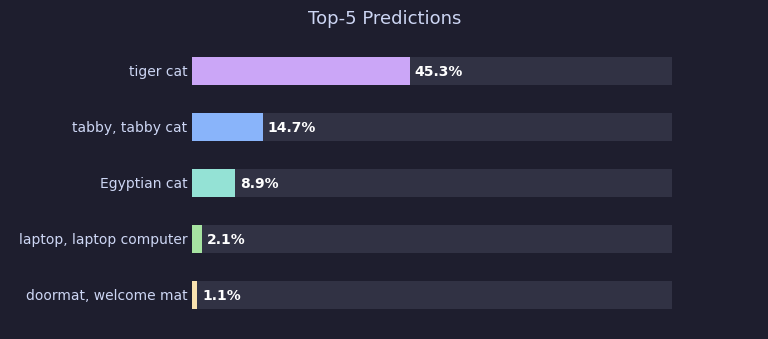

In [17]:
import matplotlib.pyplot as plt
import numpy as np

with open(LABELS_PATH, 'r') as f:
    index_to_label = json.load(f)

labels = [index_to_label[str(int(idx))] for idx in top5_indices]
probs_np = np.array(top5_probabilities, dtype=float)

labels = labels[::-1]
probs_np = probs_np[::-1]

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_h = 0.5
colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af'][::-1]

for i, (label, prob, color) in enumerate(zip(labels, probs_np, colors)):
    ax.barh(i, 1.0, height=bar_h, color='#313244', left=0)
    ax.barh(i, prob,  height=bar_h, color=color,    left=0)
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')
    ax.text(-0.01, i, label, va='center', ha='right',
            color='#cdd6f4', fontsize=10)

ax.set_xlim(-0.38, 1.18)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis('off')
ax.set_title('Top-5 Predictions', color='#cdd6f4', fontsize=13, pad=10)

plt.tight_layout()
plt.show()


### Visualisation 1 — Feature Maps After Each Block

Run `vgg_conv_block` incrementally on the input image, capturing the output after each of the 5 stages. Shows the `224→112→56→28→14→7` spatial compression and how features evolve from low-level edges to high-level semantics.

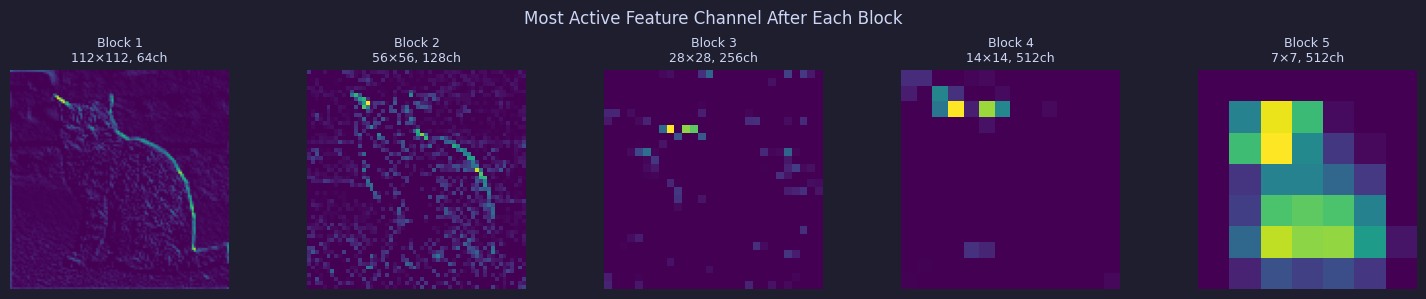

In [18]:
x = image
stage_outputs = []
for block_params in m['blocks']:
    x = vgg_conv_block(x, block_params)
    stage_outputs.append(np.array(x[0], dtype=np.float32))  # (C, H, W)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.patch.set_facecolor('#1e1e2e')

for i, (feat, ax) in enumerate(zip(stage_outputs, axes)):
    ch = np.argmax(feat.max(axis=(1, 2)))   # most active channel
    ax.imshow(feat[ch], cmap='viridis')
    ax.set_title(f"Block {i+1}\n{feat.shape[1]}×{feat.shape[2]}, {feat.shape[0]}ch",
                 color='#cdd6f4', fontsize=9)
    ax.axis('off')
    ax.set_facecolor('#1e1e2e')

plt.suptitle('Most Active Feature Channel After Each Block', color='#cdd6f4', fontsize=12)
plt.tight_layout()
plt.show()


### Visualisation 2 — First-Layer Conv Filters

`m['blocks'][0][0]['conv']['weight']` holds the 64 learned `3×3` RGB filters from the very first conv layer. Plotting them directly shows what low-level features VGG has learned to detect — classically these resemble Gabor filters: oriented edges, colour blobs, and frequency patterns.

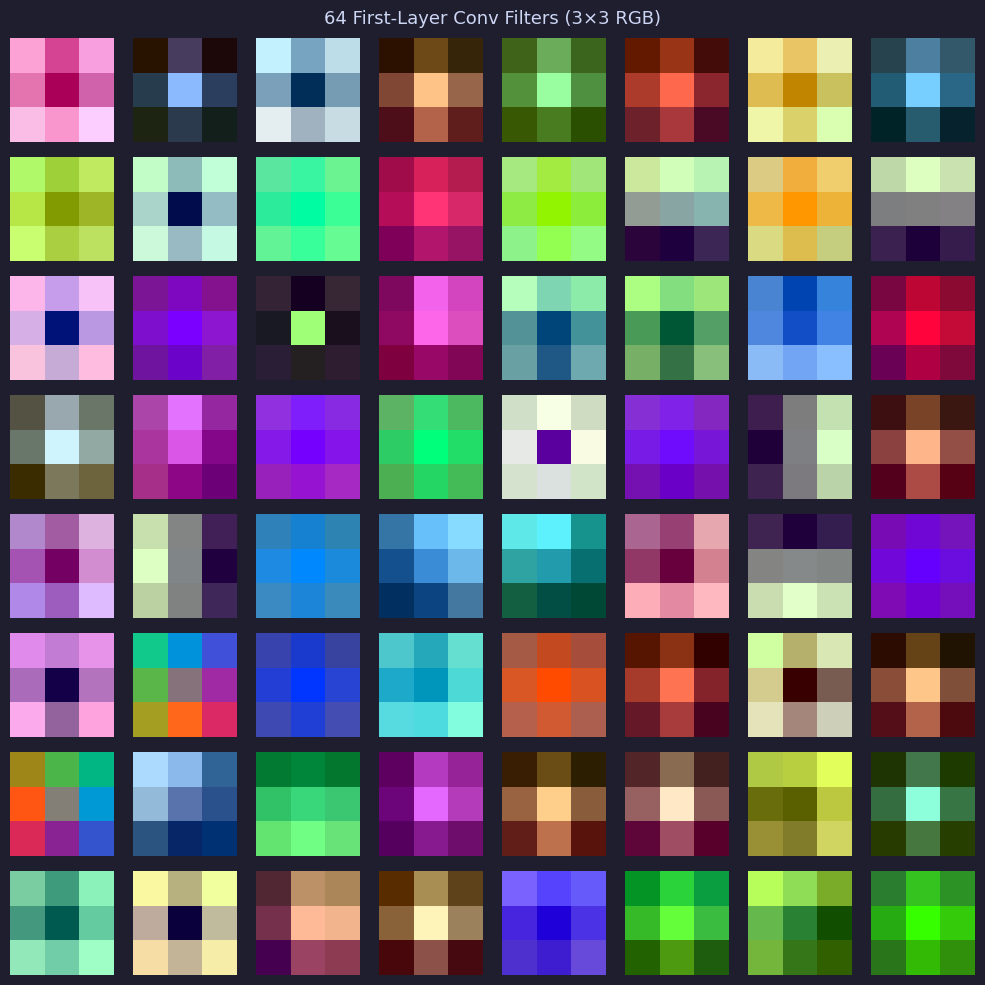

In [19]:
filters = np.array(m['blocks'][0][0]['conv']['weight'], dtype=np.float32)  # (64, 3, 3, 3)

# Normalise each filter to [0, 1] for display
f_min, f_max = filters.min(axis=(1, 2, 3), keepdims=True), filters.max(axis=(1, 2, 3), keepdims=True)
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)
filters_hwc = filters_norm.transpose(0, 2, 3, 1)  # (64, 3, 3, 3) → (64, H, W, C)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('64 First-Layer Conv Filters (3×3 RGB)', color='#cdd6f4', fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(filters_hwc[i], interpolation='nearest')
    ax.axis('off')
    ax.set_facecolor('#1e1e2e')

plt.tight_layout()
plt.show()


### Visualisation 3 — Activation Magnitude Per Block

Mean absolute activation after each block — a single scalar summarising how "energetic" the feature map is at each depth.

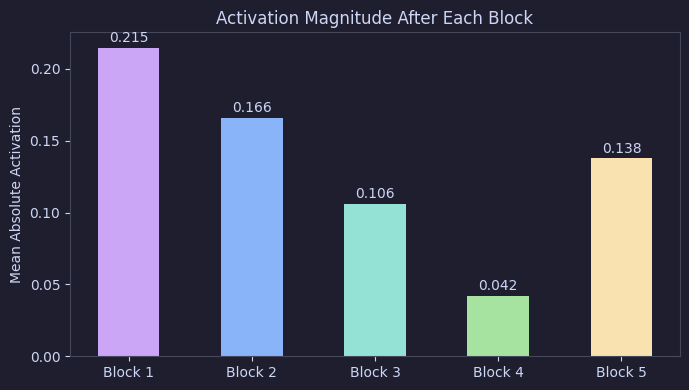

In [20]:
magnitudes = [feat.mean() for feat in stage_outputs]   # reuse stage_outputs from vis 1

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af']
bars = ax.bar([f'Block {i+1}' for i in range(5)], magnitudes, color=bar_colors, width=0.5)

for bar, val in zip(bars, magnitudes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', color='#cdd6f4', fontsize=10)

ax.set_ylabel('Mean Absolute Activation', color='#cdd6f4')
ax.set_title('Activation Magnitude After Each Block', color='#cdd6f4', fontsize=12)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()


### Visualisation 4 — Full Probability Distribution

The top-5 bar chart only shows the winners. Plotting the full 1000-class softmax output on a log scale reveals how "peaky" or spread-out VGG's confidence is — a confident model concentrates almost all probability mass on one or two classes.

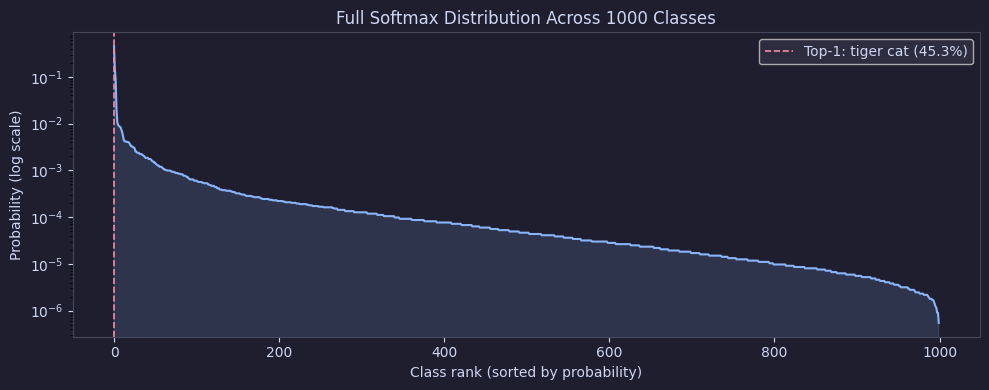

In [21]:
all_probs = np.array(probs[0], dtype=np.float32)
sorted_probs = np.sort(all_probs)[::-1]

top1_label = index_to_label[str(int(top5_indices[0]))]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.plot(sorted_probs, color='#89b4fa', linewidth=1.5)
ax.axvline(x=0, color='#f38ba8', linestyle='--', linewidth=1.2,
           label=f'Top-1: {top1_label} ({sorted_probs[0]*100:.1f}%)')
ax.fill_between(range(len(sorted_probs)), sorted_probs, alpha=0.15, color='#89b4fa')

ax.set_yscale('log')
ax.set_xlabel('Class rank (sorted by probability)', color='#cdd6f4')
ax.set_ylabel('Probability (log scale)', color='#cdd6f4')
ax.set_title('Full Softmax Distribution Across 1000 Classes', color='#cdd6f4', fontsize=12)
ax.tick_params(colors='#cdd6f4')
ax.legend(facecolor='#313244', labelcolor='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()
